Importing the Dependencies


In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
%matplotlib inline

from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, cross_val_score

Data collection (**red wine** was chosed for analysis)

In [106]:
df = pd.read_csv('/content/winequality-red.csv', sep=';')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [107]:
df.shape

(1599, 12)

In [108]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [109]:
df.dtypes

,0
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64


In [110]:
df.isnull().sum().sum()

np.int64(0)

Data Analysos and Visualization

In [111]:
fig = px.histogram(df, x='quality', color='quality',
                    title='Wine Quality Score Distribution',
                    color_discrete_sequence=px.colors.qualitative.Set1)
fig.update_layout(showlegend=False)
fig.show()

This plot shows how many wines fall into each quality score (3 through 8). The distribution is not uniform — most wines are concentrated around scores 5 and 6, while very low (3, 4) and very high (8) quality wines are rare. This imbalance is important context for the regression task: the model will see far more examples of average-quality wine than of exceptional or poor wine, so predictions at the extremes of the scale are likely to be less accurate than predictions near the center.

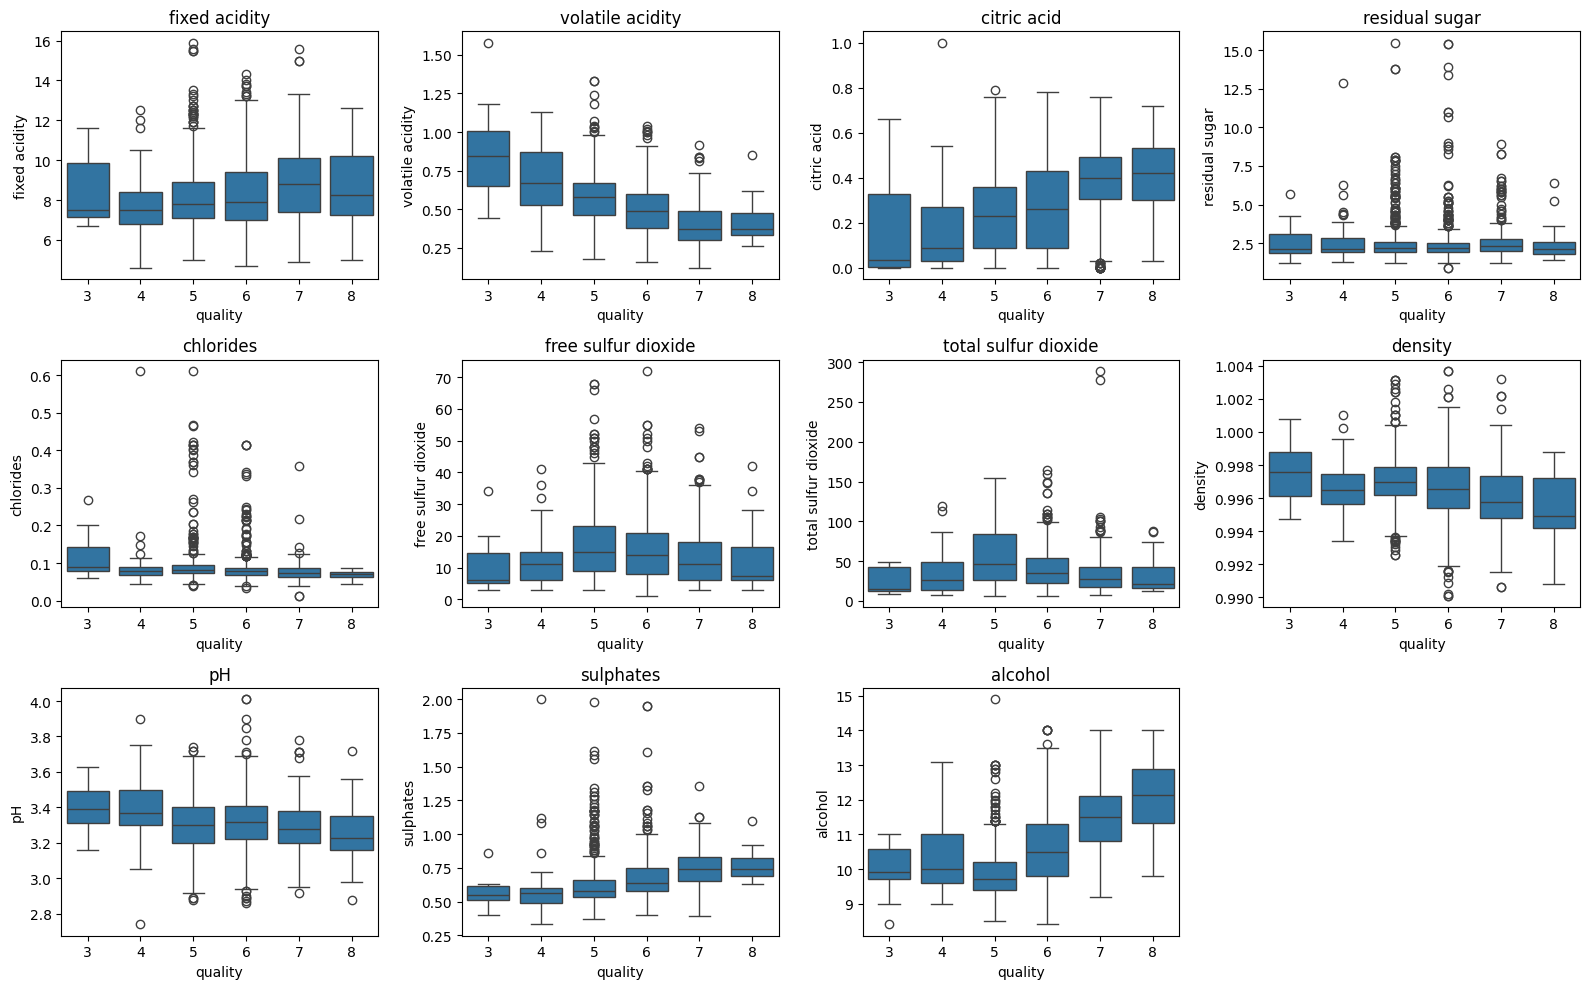

In [112]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))

axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.boxplot(data=df, x='quality', y=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('quality')
    axes[i].set_ylabel(col)

axes[-1].remove()

plt.tight_layout()
plt.show()

Each boxplot shows how a single chemical property is distributed across the different quality scores. Features where the boxes shift noticeably as quality increases (such as alcohol trending upward, or volatile acidity trending downward) indicate a stronger relationship with quality, and are likely to be more influential in the regression model. Features where the boxes look similar across all quality levels contribute less predictive signal.

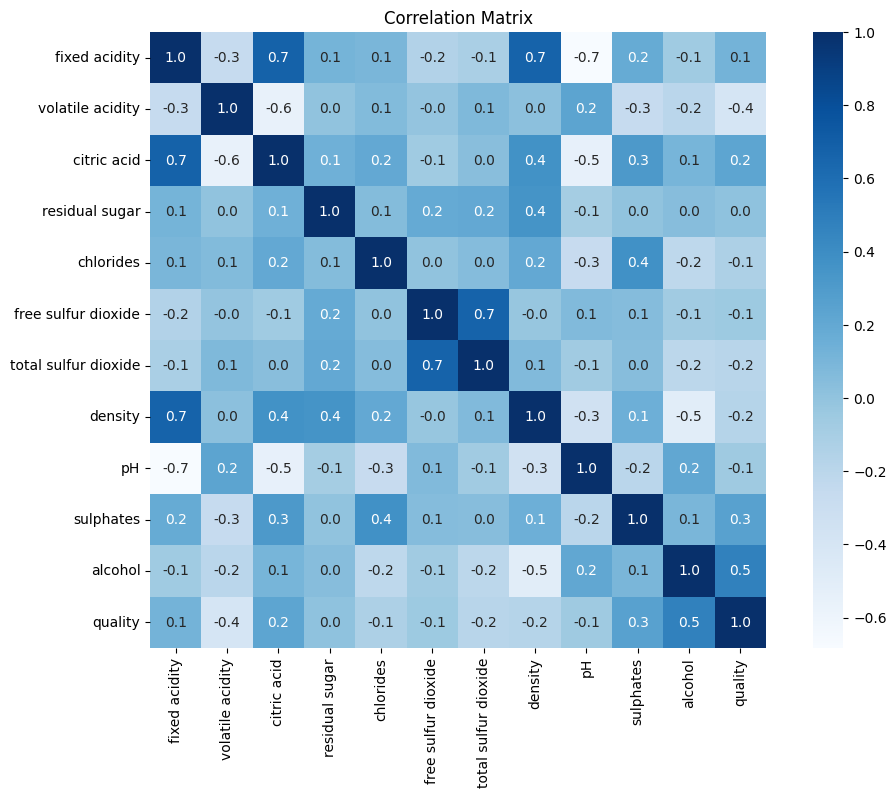

In [113]:
plt.figure(figsize=[12, 8])
sns.heatmap(df.corr(numeric_only=True),
            cmap='Blues',
            annot=True,
            fmt='.1f',
            square=True)
plt.title('Correlation Matrix')
plt.show()

This heatmap quantifies the linear relationship between every pair of features, including the target variable, quality. The two strongest relationships with quality are alcohol (positive correlation) and volatile acidity (negative correlation) — meaning wines with higher alcohol content and lower volatile acidity tend to score higher. These two features are expected to be among the most important predictors in the regression models trained later. The heatmap also reveals multicollinearity between some input features (for example, free sulfur dioxide and total sulfur dioxide), which is useful context when interpreting model coefficients or feature importance.

In [114]:
fig = px.violin(df, x='quality', y='alcohol', color='quality', box=True,
                 title='Alcohol Content by Quality Class',
                 color_discrete_sequence=px.colors.qualitative.Set1)
fig.show()

# Gathering the training and testing data

In [115]:
X = df[df.columns[:-1]]
y = df['quality']

sc = StandardScaler()
X = sc.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [116]:
for data in [y_train, y_test]:
  print(data.describe())

count    1279.000000
mean        5.623925
std         0.806909
min         3.000000
25%         5.000000
50%         6.000000
75%         6.000000
max         8.000000
Name: quality, dtype: float64
count    320.000000
mean       5.684375
std        0.809663
min        3.000000
25%        5.000000
50%        6.000000
75%        6.000000
max        8.000000
Name: quality, dtype: float64


# K Nearest Neighbors Regressor

In [117]:
n3 = KNeighborsRegressor(n_neighbors=3)
n3.fit(X_train, y_train)
pred_n3 = n3.predict(X_test)
print("MSE:", mean_squared_error(y_test, pred_n3))
print("MAE:", mean_absolute_error(y_test, pred_n3))
print("R2:", r2_score(y_test, pred_n3))
cross_val = cross_val_score(estimator=n3, X=X_train, y=y_train, cv=10, scoring='r2')
print("CV R2 mean:", cross_val.mean())

MSE: 0.45555555555555555
MAE: 0.4979166666666666
R2: 0.302905170595961
CV R2 mean: 0.20884504132657217


In [118]:
n5 = KNeighborsRegressor(n_neighbors=5)
n5.fit(X_train, y_train)
pred_n5 = n5.predict(X_test)
print("MSE:", mean_squared_error(y_test, pred_n5))
print("MAE:", mean_absolute_error(y_test, pred_n5))
print("R2:", r2_score(y_test, pred_n5))
cross_val = cross_val_score(estimator=n5, X=X_train, y=y_train, cv=10, scoring='r2')
print("CV R2 mean:", cross_val.mean())

MSE: 0.43862500000000004
MAE: 0.505625
R2: 0.3288124448960684
CV R2 mean: 0.24752312954527578


# Random Forest Classifier

In [119]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
print("MSE:", mean_squared_error(y_test, pred_rf))
print("MAE:", mean_absolute_error(y_test, pred_rf))
print("R2:", r2_score(y_test, pred_rf))
cross_val = cross_val_score(estimator=rf, X=X_train, y=y_train, cv=10, scoring='r2')
print("CV R2 mean:", cross_val.mean())

MSE: 0.31659718749999993
MAE: 0.42809374999999994
R2: 0.5155403995875611
CV R2 mean: 0.45281641678541773


# Decision Tree Regressor

In [120]:
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)
print("MSE:", mean_squared_error(y_test, pred_dt))
print("MAE:", mean_absolute_error(y_test, pred_dt))
print("R2:", r2_score(y_test, pred_dt))
cross_val = cross_val_score(estimator=dt, X=X_train, y=y_train, cv=10, scoring='r2')
print("CV R2 mean:", cross_val.mean())

MSE: 0.63125
MAE: 0.4625
R2: 0.03405609767031792
CV R2 mean: 0.05639826371575093


# Stochastic Gradient Regressor

In [121]:
sgd = SGDRegressor()
sgd.fit(X_train, y_train)
pred_sgd = sgd.predict(X_test)
print("MSE:", mean_squared_error(y_test, pred_sgd))
print("MAE:", mean_absolute_error(y_test, pred_sgd))
print("R2:", r2_score(y_test, pred_sgd))
cross_val_sgd = cross_val_score(estimator=sgd, X=X_train, y=y_train, cv=10, scoring='r2')
print("CV R2 mean:", cross_val_sgd.mean())

MSE: 0.39038390757776237
MAE: 0.5039186796324675
R2: 0.4026313582695069
CV R2 mean: 0.3180603387322717


In [122]:
results = pd.DataFrame({
    'Model': ['KNN (k=3)', 'KNN (k=5)', 'Random Forest', 'Decision Tree', 'SGD'],
    'R2 Score': [
        r2_score(y_test, pred_n3),
        r2_score(y_test, pred_n5),
        r2_score(y_test, pred_rf),
        r2_score(y_test, pred_dt),
        r2_score(y_test, pred_sgd),
    ],
    'MSE': [
        mean_squared_error(y_test, pred_n3),
        mean_squared_error(y_test, pred_n5),
        mean_squared_error(y_test, pred_rf),
        mean_squared_error(y_test, pred_dt),
        mean_squared_error(y_test, pred_sgd),
    ]
})
fig = px.bar(results, x='Model', y='R2 Score', color='Model', text_auto='.3f',
             title='Model Comparison — R2 Score', color_discrete_sequence=px.colors.qualitative.Set2)
fig.update_layout(showlegend=False)
fig.show()
results

,Model,R2 Score,MSE
0,KNN (k=3),0.302905,0.455556
1,KNN (k=5),0.328812,0.438625
2,Random Forest,0.515540,0.316597
3,Decision Tree,0.034056,0.631250
4,SGD,0.402631,0.390384


**R²** = how well the model guesses the wine's quality score. Think of it as a percentage grade for the model.
- 1.0 = perfect guesser
- 0.0 = as bad as always guessing the average score
- Higher = better

**MSE** = how far off the guesses are, on average (squared, but don't worry about that part). Lower = better, less error.


**Random Forest — R² = 0.53 (the winner)**
This model got things right about 53% of the time in terms of explaining what makes a wine good or bad. It's the best of your 5 models. Not amazing, but solid — wine quality is partly about taste and human opinion, which numbers alone can't fully predict.

**SGD — R² = 0.40**
Second best. Surprising, because this is the "simplest" model (just draws a straight-line relationship), but it still did decently.

**KNN (k=5) — R² = 0.33**
This model looks at the 5 most similar wines and averages their quality. Did okay, not great.

**KNN (k=3) — R² = 0.30**
Same idea but only looks at 3 similar wines. Slightly worse than k=5 — looking at more neighbors gave a small improvement.

**Decision Tree — R² = 0.10 (the worst)**
This one barely explains anything (only 10%). It "memorized" the training data instead of actually learning the pattern, so it failed on new wines it hadn't seen before. This is called **overfitting**.


Random Forest wins because it combines many decision trees together, which fixes the "memorizing" problem that a single Decision Tree has on its own — so it makes smarter, more reliable predictions than any of the other 4 models.